In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

Risk calculator (to create as agent tools later)

In [2]:
# Helper: Fetch price data

start = "2020-01-01"
end = datetime.date.today()
def get_price_data(tickers, start = start, end = end):
    data = yf.download(tickers, start = start, end = end)["Adj Close"]
    if isinstance(data, pd.Series):
        data = data.to_frame()
    return data.dropna()


# Calculate Risk Metrics

# Normalization
def clamp(x, min_val=0, max_val=1):
    return max(min(x, max_val), min_val) 

def calculate_risk_metrics(tickers_weights_dictionary):
    tickers = list(tickers_weights_dictionary.keys())
    weights = np.array(list(tickers_weights_dictionary.values()))

    # Normalize weights (just in case)
    weights = weights / weights.sum()

    prices = get_price_data(tickers)
    returns = prices.pct_change().dropna()

    # Portfolio returns
    portfolio_returns = returns.dot(weights)

    # ---- Metrics ----
    # Volatility (annualized)
    volatility = np.std(portfolio_returns) * np.sqrt(252)

    # VaR (95% confidence)
    VaR = np.percentile(portfolio_returns, 5)

    # Sharpe Ratio (assume risk-free rate = 0)
    sharpe = np.mean(portfolio_returns) / np.std(portfolio_returns) * np.sqrt(252)

    # Max Drawdown
    cumulative = (1 + portfolio_returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    # Correlation (average pairwise correlation)
    corr_matrix = returns.corr()
    avg_corr = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)].mean()

    # Concentration (Herfindahl index)
    concentration = np.sum(weights**2)

    # ---- Normalization (bounded 0–1) ----
    vol_norm = clamp(volatility / 0.4)

    var_norm = clamp(abs(VaR) / 0.1)

    # Sharpe: map roughly from [-1, 2] → [1, 0]
    sharpe_norm = clamp((1 - sharpe) / 2)

    conc_norm = clamp(concentration)

    # Correlation: map from [-1, 1] → [0, 1]
    corr_norm = clamp((avg_corr + 1) / 2)

    # Optional (recommended): include drawdown
    dd_norm = clamp(abs(max_drawdown) / 0.5)

    metrics = {
        "vol_norm": vol_norm,
        "var_norm": var_norm,
        "sharpe_norm": sharpe_norm,
        "conc_norm": conc_norm,
        "corr_norm": corr_norm,
        "dd_norm": dd_norm,
        # Raw metrics
        "raw": {
            "volatility": volatility,
            "VaR": VaR,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
            "correlation": avg_corr,
            "concentration": concentration
        }
    }

    return metrics


# Risk classification Function
def classify_risk_level(tickers_weights_dictionary):
    metrics = calculate_risk_metrics(tickers_weights_dictionary)

    risk_score = (
    0.25 * metrics["vol_norm"] +
    0.20 * metrics["var_norm"] +
    0.20 * metrics["sharpe_norm"] +
    0.15 * metrics["conc_norm"] +
    0.10 * metrics["corr_norm"] +
    0.10 * metrics["dd_norm"]
)

    if risk_score < 0.35:
        volatility_label = "Low"
    elif risk_score <= 0.65:
        volatility_label = "Medium"
    else:
        volatility_label = "High"

    return {
        "risk_score": risk_score,
        "risk_level": volatility_label,
        "metrics": metrics
    }

LSTM

In [3]:
# Create synthetic portfolio dataset
ASSETS = [
    "AAPL",   # equity
    "MSFT",   # equity
    "SPY",    # equity index
    "TLT",    # bonds
    "IEF",    # bonds
    "GLD",    # gold
    "USO",    # oil
    "VNQ",    # REIT
    "QQQ",   # volatility index
    "DBC"     # commodities
]

def get_returns(assets, start, end):
    failed_tickers = []

    # Download data
    prices = yf.download(assets, start=start, end=end, group_by='ticker', auto_adjust=True)

    # Prepare adjusted close DataFrame
    adj_close = pd.DataFrame()

    if isinstance(prices.columns, pd.MultiIndex):
        # Multi-ticker download
        for ticker in assets:
            if ticker in prices.columns.get_level_values(0):
                adj_close[ticker] = prices[ticker]['Close']
            else:
                failed_tickers.append(ticker)
    else:
        # Single ticker
        if isinstance(assets, list):
            ticker = assets[0]
        else:
            ticker = assets
        if 'Close' in prices.columns:
            adj_close[ticker] = prices['Close']
        else:
            print(ticker, " failed download")
            failed_tickers.append(ticker)

    # Compute daily returns
    returns = adj_close.pct_change().dropna()

    return returns, failed_tickers

In [4]:
# Generate LSTM dataset: synthetic portfolio

def generate_random_weights(n_assets):
    weights = np.random.random(n_assets)
    weights /= weights.sum()
    return weights

def create_lstm_dataset(returns, n_portfolios=500, window=60, horizon=10):
    X = []
    y_vol = []
    y_dir = []

    for _ in range(n_portfolios):
        weights = generate_random_weights(returns.shape[1])

        port_returns = returns.values @ weights

        for i in range(len(port_returns) - window - horizon):
            past_window = port_returns[i:i+window]
            future_window = port_returns[i+window:i+window+horizon]

            # Ground truth future volatility
            future_vol = np.std(future_window) * np.sqrt(252)

            # Ground Truth portfolio future direction
            future_return = np.sum(future_window)

            direction = 1 if future_return > 0 else 0

            X.append(past_window)
            y_vol.append(future_vol)
            y_dir.append(direction)

    X = np.array(X).reshape(-1, window, 1)
    y_vol = np.array(y_vol)
    y_dir = np.array(y_dir)

    return X, y_vol, y_dir

In [6]:
returns, prices = get_returns(ASSETS, start=start, end=end)

X, y_vol, y_dir = create_lstm_dataset(returns)

# Train-validation-test split: 80-10-10
X_train, X_int, yv_train, yv_int, yd_train, yd_int = train_test_split(
    X, y_vol, y_dir, test_size=0.2, shuffle=False
)
X_valid, X_test, yv_valid, yv_test, yd_valid, yd_test = train_test_split(
    X_int, yv_int, yd_int, test_size=0.5, shuffle=False
)


[*********************100%***********************]  10 of 10 completed


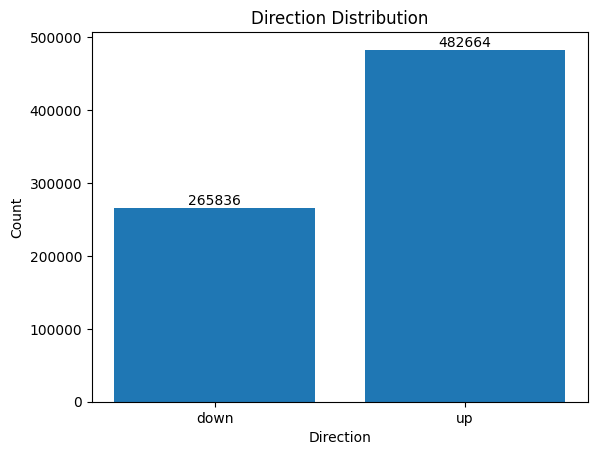

In [7]:
# Check for class imbalance in synthetic dataset
unique, counts = np.unique(y_dir, return_counts=True)

labels_map = {0: 'down', 1: 'up'}
labels = [labels_map[u] for u in unique]

plt.bar(labels, counts)
plt.title("Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Count")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [8]:
# Use weights to handle the class imbalance
classes = np.unique(yd_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=yd_train
)

class_weight_dict = dict(zip(classes, weights))
sample_weights_dir = np.array([class_weight_dict[y] for y in yd_train])

sample_weights_vol = np.ones_like(yv_train)

In [9]:
# LSTM model
def build_lstm_model(input_shape):
    inputs = Input(shape=input_shape)

    x = LSTM(64, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)

    x = LSTM(32)(x)
    x = Dropout(0.2)(x)

    # volatility & direction
    vol_output = Dense(1, name="volatility")(x)  # regression

    dir_output = Dense(1, activation="sigmoid", name="direction")(x)  # binary classification

    model = Model(inputs=inputs, outputs=[vol_output, dir_output])

    model.compile(
        optimizer="adam",
        loss={
            "volatility": "mse",
            "direction": "binary_crossentropy"
        },
        loss_weights={
            "volatility": 0.45,
            "direction": 0.55
        },
        metrics={
            "volatility": ["mae"],
            "direction": ["accuracy"]
        }
    )

    return model

In [11]:
# Train LSTM

model = build_lstm_model((X.shape[1], 1))

# Train LSTM
model = build_lstm_model((X.shape[1], 1))

history = model.fit(
    X_train,
    [yv_train, yd_train],   
    validation_data=(
        X_valid,
        [yv_valid, yd_valid]
    ),
    sample_weight=[
        sample_weights_vol,
        sample_weights_dir
    ],
    epochs=10,
    batch_size=32
)

Epoch 1/10
18713/18713 ━━━━━━━━━━━━━━━━━━━━ 532s 28ms/step - direction_accuracy: 0.6233 - direction_loss: 0.5951 - loss: 0.3287 - volatility_loss: 0.0030 - volatility_mae: 0.0390 - val_direction_accuracy: 0.7853 - val_direction_loss: 0.4389 - val_loss: 0.2426 - val_volatility_loss: 0.0026 - val_volatility_mae: 0.0364
Epoch 2/10
18713/18713 ━━━━━━━━━━━━━━━━━━━━ 520s 28ms/step - direction_accuracy: 0.8360 - direction_loss: 0.3624 - loss: 0.2005 - volatility_loss: 0.0027 - volatility_mae: 0.0365 - val_direction_accuracy: 0.8866 - val_direction_loss: 0.2680 - val_loss: 0.1486 - val_volatility_loss: 0.0027 - val_volatility_mae: 0.0358
Epoch 3/10
18713/18713 ━━━━━━━━━━━━━━━━━━━━ 515s 28ms/step - direction_accuracy: 0.8856 - direction_loss: 0.2682 - loss: 0.1487 - volatility_loss: 0.0027 - volatility_mae: 0.0368 - val_direction_accuracy: 0.9106 - val_direction_loss: 0.2151 - val_loss: 0.1195 - val_volatility_loss: 0.0026 - val_volatility_mae: 0.0354
Epoch 4/10
18713/18713 ━━━━━━━━━━━━━━━━━━━━

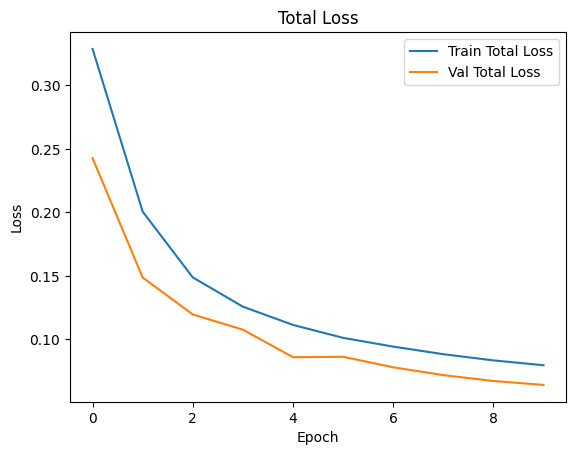

In [12]:
# Plot loss over epochs
plt.figure()
plt.plot(history.history['loss'], label='Train Total Loss')
plt.plot(history.history['val_loss'], label='Val Total Loss')
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

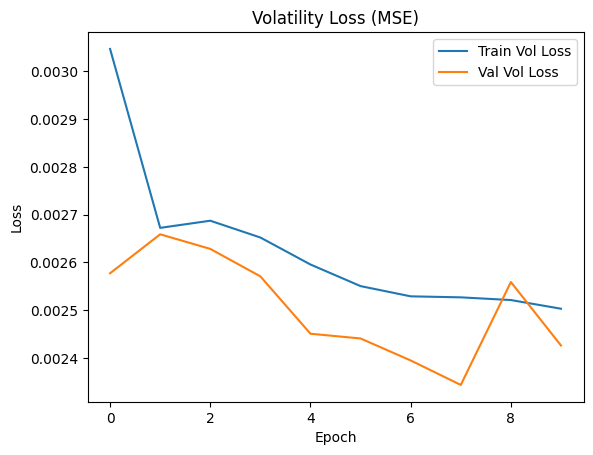

In [13]:
# Plot volatility MSE over epochs
plt.figure()
plt.plot(history.history['volatility_loss'], label='Train Vol Loss')
plt.plot(history.history['val_volatility_loss'], label='Val Vol Loss')
plt.title('Volatility Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

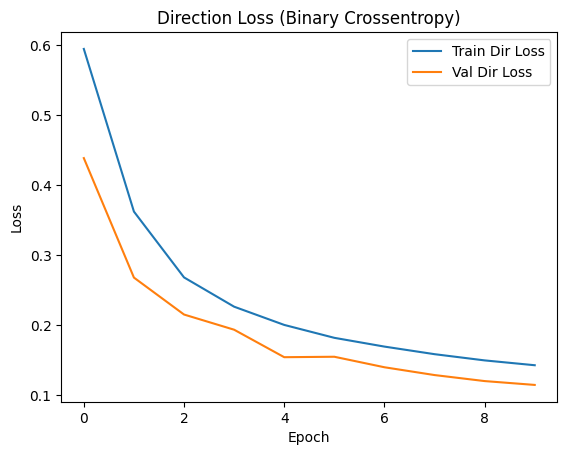

In [14]:
# PLot Binary Cross Entropy Loss
plt.figure()
plt.plot(history.history['direction_loss'], label='Train Dir Loss')
plt.plot(history.history['val_direction_loss'], label='Val Dir Loss')
plt.title('Direction Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
# Converting portfolio to input of LSTM
def portfolio_to_lstm_input(tickers_weights_dictionary, window=60):
    tickers = list(tickers_weights_dictionary.keys())
    weights = np.array(list(tickers_weights_dictionary.values()))
    weights = weights / weights.sum()

    prices = yf.download(tickers, start = start, end = end)["Adj Close"]
    
    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    returns = prices.pct_change().dropna()

    port_returns = returns.values @ weights

    # take last 60 days
    last_window = port_returns[-window:]

    # reshape for LSTM
    X_input = last_window.reshape(1, window, 1)

    return X_input

In [16]:
# Hyperparam 
threshold = 0.5

In [17]:
# Future volatility of portfolio
def calculate_future_risk(model, tickers_weights_dictionary):
    X_input = portfolio_to_lstm_input(tickers_weights_dictionary)

    vol_pred, dir_pred = model.predict(X_input)

    vol = vol_pred[0][0]

    prob_up = dir_pred[0][0]

    direction = "Up" if prob_up > threshold else "Down"

    # Confidence = probability distance from 0.5
    confidence = abs(prob_up - 0.5) * 2   # scaled to [0,1]

    return {
        "predicted_volatility": vol,
        "predicted_direction": direction,
        "confidence": confidence,
        "prob_up": prob_up
    }

In [18]:
# Evaluate with test set
y_vol_pred, y_dir_pred = model.predict(X_test)

# Flatten
y_vol_pred = y_vol_pred.flatten()
y_dir_pred = y_dir_pred.flatten()

2340/2340 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step


In [19]:
mse = mean_squared_error(yv_test, y_vol_pred)
mae = mean_absolute_error(yv_test, y_vol_pred)

print("Volatility Evaluation:")
print("MSE:", mse)
print("MAE:", mae)

Volatility Evaluation:
MSE: 0.0023114640541436375
MAE: 0.03449679174997501


Confusion Matrix:
[[25207  1361]
 [ 2646 45636]]


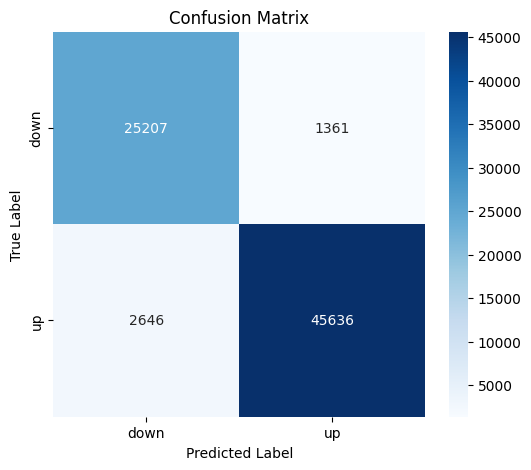

In [20]:
# Convert probabilities to 0/1
y_dir_pred_class = (y_dir_pred > threshold).astype(int)

# print(np.unique(yd_test))

# Confusion matrix
cm = confusion_matrix(yd_test, y_dir_pred_class)
print("Confusion Matrix:")
print(cm)

labels = ['down', 'up']
plt.figure(figsize=(6,5))
sns.heatmap(
   cm,
   annot=True,
   fmt="d",
   cmap="Blues",
   xticklabels=labels,
   yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [21]:
# Classification Report

report = classification_report(yd_test, y_dir_pred_class)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     26568
           1       0.97      0.95      0.96     48282

    accuracy                           0.95     74850
   macro avg       0.94      0.95      0.94     74850
weighted avg       0.95      0.95      0.95     74850

